# F1 Race Position Predictor

Predicts F1 race finishing positions using historical race and qualifying data (2020-2025).
Trained on 2020-2024, evaluated on 2025.

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import average_precision_score
from scipy.stats import kendalltau, spearmanr
import fastf1

## Data Fetching (Optional)

These cells fetch raw data via fastf1. They are commented out since CSVs already exist.
Uncomment and run only when fetching new race data.

In [28]:
session = fastf1.get_session(2026,"Australian Grand Prix","r")
session.load(telemetry= False, weather = False, messages = False)

results = session.results

results = results.drop(columns=["BroadcastName", "Abbreviation", "TeamColor", "HeadshotUrl", "CountryCode", "ClassifiedPosition"])
print(results.columns)
print(results.head(5))
results.to_csv('AustralianGpP.csv', index = False)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


Index(['DriverNumber', 'DriverId', 'TeamName', 'TeamId', 'FirstName',
       'LastName', 'FullName', 'Position', 'GridPosition', 'Q1', 'Q2', 'Q3',
       'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
   DriverNumber   DriverId  TeamName    TeamId FirstName   LastName  \
63           63    russell  Mercedes  mercedes    George    Russell   
12           12  antonelli  Mercedes  mercedes      Kimi  Antonelli   
16           16    leclerc   Ferrari   ferrari   Charles    Leclerc   
44           44   hamilton   Ferrari   ferrari     Lewis   Hamilton   
1             1     norris   McLaren   mclaren     Lando     Norris   

           FullName  Position  GridPosition  Q1  Q2  Q3  \
63   George Russell       1.0           1.0 NaT NaT NaT   
12   Kimi Antonelli       2.0           2.0 NaT NaT NaT   
16  Charles Leclerc       3.0           4.0 NaT NaT NaT   
44   Lewis Hamilton       4.0           7.0 NaT NaT NaT   
1      Lando Norris       5.0           6.0 NaT NaT NaT   

     

In [29]:

# def time_to_seconds(t):
#     try:
#         return round(pd.to_timedelta(str(t)).total_seconds(), 3)
#     except:
#         return None

# def load_race_weekend(year, round_num):
#     try:
#         # Qualifying
#         quali = fastf1.get_session(year, round_num, 'Q')
#         quali.load(telemetry=False, weather=False, messages=False)
        
#         quali_df = quali.results[[
#             'DriverNumber', 'FullName', 'TeamName',
#             'Position', 'Q1', 'Q2', 'Q3'
#         ]].copy()
#         quali_df = quali_df.rename(columns={'Position': 'GridPosition'})
#         quali_df['Q1_seconds'] = quali_df['Q1'].apply(time_to_seconds)
#         quali_df['Q2_seconds'] = quali_df['Q2'].apply(time_to_seconds)
#         quali_df['Q3_seconds'] = quali_df['Q3'].apply(time_to_seconds)
#         quali_df = quali_df.drop(columns=['Q1', 'Q2', 'Q3'])

#         # Race
#         race = fastf1.get_session(year, round_num, 'R')
#         race.load(telemetry=False, weather=False, messages=False)
        
#         race_df = race.results[['FullName', 'Position', 'Status', 'Points', 'Time']].copy()
#         race_df['TimeDelta'] = race_df['Time'].apply(time_to_seconds)
#         race_df = race_df.rename(columns={'Position': 'RacePosition'})
#         race_df = race_df.drop(columns='Time')

#         # Merge
#         merged = pd.merge(quali_df, race_df, on='FullName', how='inner')
#         merged['Season'] = year
#         merged['Round'] = round_num
#         merged['EventName'] = race.event['EventName']
#         merged['FinishPosition'] = pd.to_numeric(merged['RacePosition'], errors='coerce')

#         return merged

#     except Exception as e:
#         print(f"  âœ— Round {round_num} skipped: {e}")
#         return None


# # â”€â”€ Run with resume support â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# all_seasons = []

# for year in range(2025, 2026):
#     print(f"\n{'='*40}")
#     print(f"  Loading {year}...")
#     print(f"{'='*40}")

#     season_file = f'data/f1_{year}.csv'
#     schedule = fastf1.get_event_schedule(year, include_testing=False)
#     all_rounds = list(schedule['RoundNumber'])

#     # â”€â”€ Resume logic â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     existing_df = None
#     completed_rounds = set()

#     if os.path.exists(season_file):
#         existing_df = pd.read_csv(season_file)
#         completed_rounds = set(existing_df['Round'].unique())
#         print(f"  âœ“ Found existing data â€” {len(completed_rounds)} rounds already loaded: {sorted(completed_rounds)}")
    
#     remaining_rounds = [r for r in all_rounds if r not in completed_rounds]

#     if not remaining_rounds:
#         print(f"  âœ“ All rounds complete â€” loading from CSV")
#         all_seasons.append(existing_df)
#         continue

#     print(f"  â†’ Rounds to fetch: {remaining_rounds}")

#     # â”€â”€ Fetch missing rounds â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     season_data = []
#     for round_num in remaining_rounds:
#         print(f"Loading round {round_num}...", end=' ')
#         df = load_race_weekend(year, round_num)
#         if df is not None:
#             season_data.append(df)
#             print(f"âœ“ {df['EventName'].iloc[0]}")
#         time.sleep(3)

#     # â”€â”€ Merge new data with existing and save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     frames = []
#     if existing_df is not None:
#         frames.append(existing_df)
#     if season_data:
#         frames.append(pd.concat(season_data, ignore_index=True))

#     if frames:
#         year_df = pd.concat(frames, ignore_index=True)
#         year_df = year_df.sort_values('Round').reset_index(drop=True)  # keep rounds in order
#         year_df.to_csv(season_file, index=False)
#         print(f"  âœ“ Saved {len(year_df['Round'].unique())} total rounds for {year}")
#         all_seasons.append(year_df)

#     print(f"\nDone!")

In [30]:

# Load and combine all seasons
years = range(2020, 2026)  # 2020-2024
dfs = [pd.read_csv(f'data/f1_{year}.csv') for year in years]

combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values(['Season', 'Round']).reset_index(drop=True)


combined.to_csv('data/f1_2020_2025.csv', index=False)
print(f"Combined dataset: {len(combined)} rows across {combined['Season'].nunique()} seasons")

Combined dataset: 2617 rows across 6 seasons


## Data Loading

Load the combined dataset and sort chronologically.

In [31]:
df = pd.read_csv('data/f1_2020_2025.csv')
df = df.sort_values(['Season', 'Round']).reset_index(drop=True)
raw_2025 = pd.read_csv('data/f1_2025.csv')
print(f"Loaded {len(df)} rows across {df['Season'].nunique()} seasons ({int(df['Season'].min())}-{int(df['Season'].max())})")

Loaded 2617 rows across 6 seasons (2020-2025)


## Exploratory Data Analysis

Initial exploration of the raw data before feature engineering.
These cells use temporary copies to avoid mutating the main dataframe.

In [32]:
# Raw feature correlation with RacePosition (before feature engineering)
_eda = df.drop(columns=['Time', 'Podium', 'Points', 'Status', 'DriverNumber'], errors='ignore')


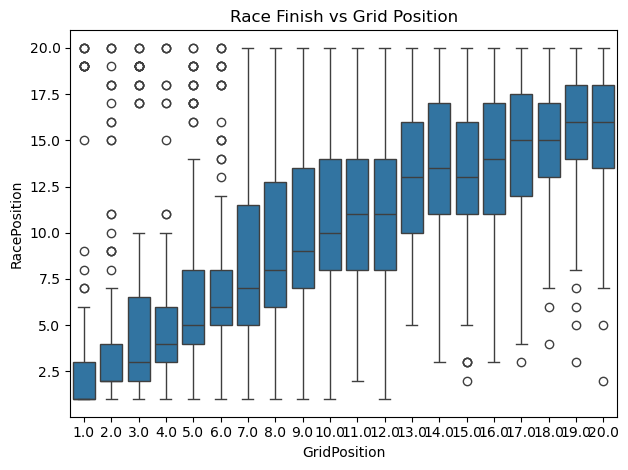

In [33]:
sns.boxplot(data=df, x='GridPosition', y='RacePosition')
plt.title('Race Finish vs Grid Position')
plt.tight_layout()
plt.show()

In [34]:
# Per-year team performance summary
for year in range(2020, 2025):
    _yr = pd.read_csv(f'data/f1_{year}.csv')
    stats = _yr.groupby('TeamName')['RacePosition'].agg(['mean', 'std']).sort_values('mean')
    print(f"\n{'=' * 40}")
    print(f" Team Stats for {year}")
    print(f"{'=' * 40}")
    print(stats)


 Team Stats for 2020
                        mean       std
TeamName                              
Mercedes            3.735294  4.223375
Red Bull Racing     7.705882  6.206201
McLaren             8.617647  4.817988
Renault             8.941176  4.741443
Racing Point        9.205882  5.902128
Ferrari            10.705882  5.390954
AlphaTauri         10.705882  4.713163
Alfa Romeo Racing  13.852941  2.786682
Williams           15.735294  2.632073
Haas F1 Team       15.794118  2.804535

 Team Stats for 2021
                        mean       std
TeamName                              
Mercedes            5.409091  5.743827
Red Bull Racing     5.840909  6.069149
Ferrari             7.113636  3.948599
McLaren             7.795455  3.915263
Alpine             10.250000  4.636182
AlphaTauri         11.272727  5.271087
Aston Martin       12.000000  4.404015
Alfa Romeo Racing  13.204545  2.698661
Williams           14.727273  3.787149
Haas F1 Team       17.325581  1.972682

 Team Stats for 202

## Feature Engineering

All rolling features use `.shift(1)` before aggregation to prevent look-ahead leakage.
The model never sees the current race's data when computing features.

### Driver Rolling Features

In [35]:
# Rolling averages capture recent form — shift(1) ensures no leakage
df['driver_rolling_avg_3'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
df['driver_rolling_avg_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['driver_rolling_std_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).std())
)
df['driver_last_finish'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1))
)
print("Added: driver_rolling_avg_3, driver_rolling_avg_5, driver_rolling_std_5, driver_last_finish")

Added: driver_rolling_avg_3, driver_rolling_avg_5, driver_rolling_std_5, driver_last_finish


### Team Rolling Features

In [36]:
df['team_rolling_avg_5'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['team_rolling_avg_3'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
print("Added: team_rolling_avg_5, team_rolling_avg_3")

Added: team_rolling_avg_5, team_rolling_avg_3


### Team Performance x Grid Position

### Qualifying Features

In [37]:
# Best qualifying time (Q3 > Q2 > Q1 fallback) and delta to teammate
df['best_q_time'] = df['Q3_seconds'].fillna(df['Q2_seconds']).fillna(df['Q1_seconds'])
teammate_avg = df.groupby(['Season', 'Round', 'TeamName'])['best_q_time'].transform('mean')
df['quali_delta_to_teammate'] = df['best_q_time'] - teammate_avg
print("Added: best_q_time, quali_delta_to_teammate")

Added: best_q_time, quali_delta_to_teammate


### Track-Specific Driver History

In [38]:
# Historical avg finish at this specific circuit from all prior seasons
# Validated via Spearman correlation (rho=0.311, p<1e-13) — moderate but real signal
df = df.sort_values(['FullName', 'EventName', 'Season', 'Round'])
df['driver_track_history_avg'] = (
    df.groupby(['FullName', 'EventName'])['RacePosition']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)
# Fill NaN (first appearance at a circuit) with driver's overall rolling avg
df['driver_track_history_avg'] = df['driver_track_history_avg'].fillna(df['driver_rolling_avg_5'])
print(f"Added: driver_track_history_avg (NaN remaining: {df['driver_track_history_avg'].isna().sum()})")

Added: driver_track_history_avg (NaN remaining: 40)


### Data Cleanup & Encoding

Rename RacePosition to FinishPosition, engineer TimeDelta rolling features,
drop leakage columns, and one-hot encode categoricals.

In [39]:
# Rename and drop redundant columns
df = df.drop(columns=['DriverNumber'], errors='ignore')
df = df.rename(columns={'RacePosition': 'FinishPosition'})

# TimeDelta: set winner to 0, fill DNFs with 300s proxy
df = df.sort_values(['FullName', 'Season', 'Round'])
df.loc[df['FinishPosition'] == 1, 'TimeDelta'] = 0
df['TimeDelta'] = df['TimeDelta'].fillna(300)

# Rolling TimeDelta features
df['driver_rolling_avg_timedelta_3'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
df['driver_rolling_avg_timedelta_5'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
# Fill NaN with training-set mean only (no leakage from 2025)
train_timedelta_mean = df[df['Season'] <= 2024]['TimeDelta'].mean()
df['driver_rolling_avg_timedelta_3'] = df['driver_rolling_avg_timedelta_3'].fillna(train_timedelta_mean)
df['driver_rolling_avg_timedelta_5'] = df['driver_rolling_avg_timedelta_5'].fillna(train_timedelta_mean)

# Drop leakage columns
leakage = ['Points', 'TimeDelta', 'TimeDetla', 'Podium', 'Status', 'Time']
df = df.drop(columns=leakage, errors='ignore')

#  One-hot encode categoricals
df_ref = df[['Season', 'Round', 'EventName', 'FullName', 'FinishPosition']].copy()

teamDummy   = pd.get_dummies(df['TeamName'],  prefix='Team')

df = df.drop(columns=['TeamName', 'FullName', 'EventName'])
df = pd.concat([df, teamDummy], axis=1)

# Drop rows missing qualifying data, then drop intermediate columns
df = df.dropna(subset=['best_q_time'])
df = df.drop(columns=['driver_rolling_avg_timedelta_3', 'team_rolling_avg_3', 'driver_rolling_avg_3',
                       'Q1_seconds', 'Q2_seconds', 'Q3_seconds', 'best_q_time'])

print(f"Final shape: {df.shape}")

Final shape: (2589, 27)


## Feature Analysis


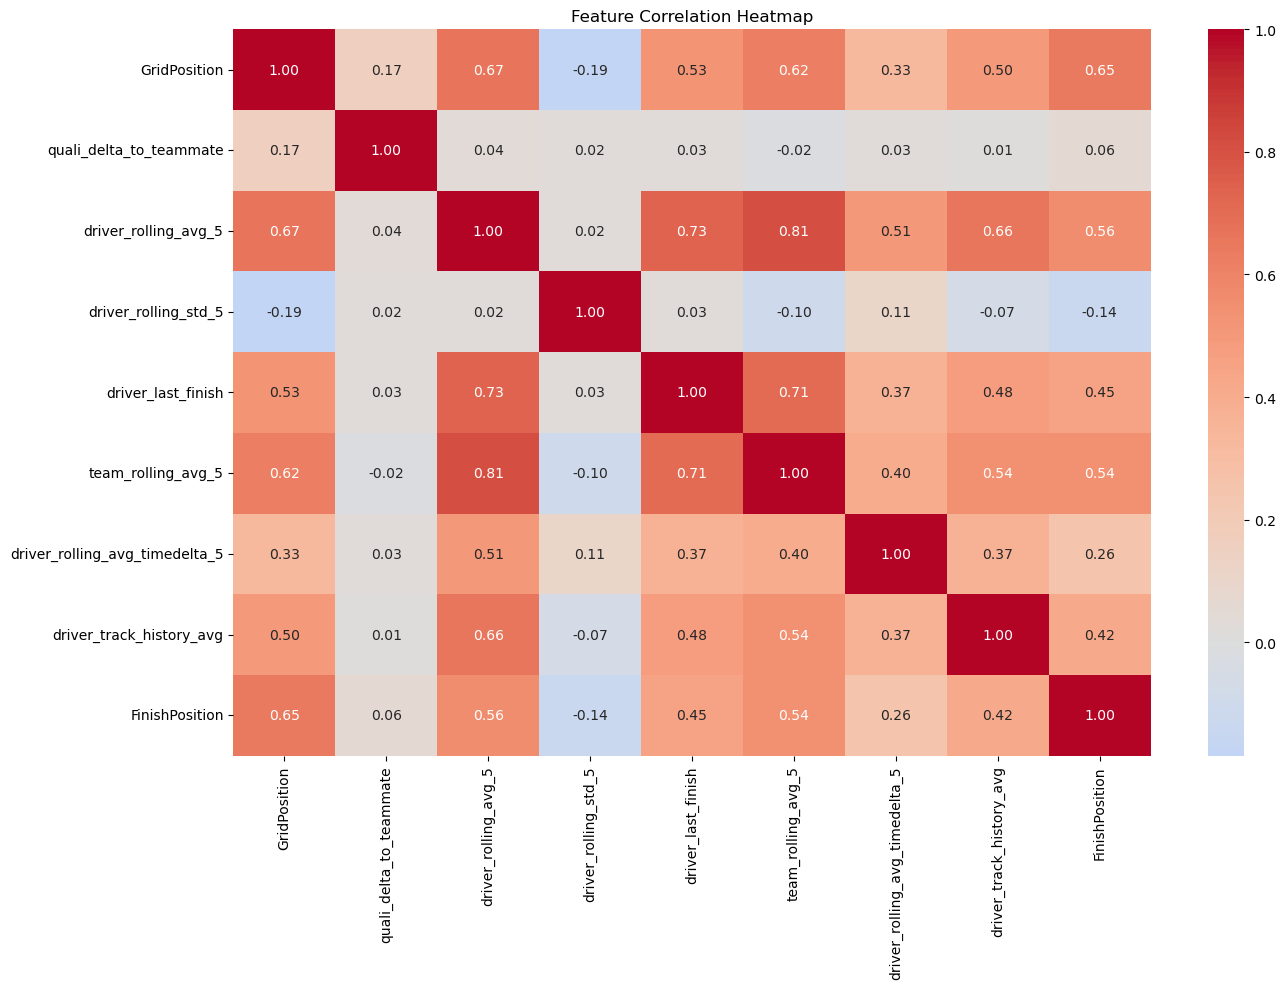

In [40]:
# Numeric feature correlation heatmap
numeric_cols = ['GridPosition', 'quali_delta_to_teammate',
                'driver_rolling_avg_5', 'driver_rolling_std_5', 'driver_last_finish',
                'team_rolling_avg_5',
                'driver_rolling_avg_timedelta_5', 'driver_track_history_avg', 'FinishPosition']
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Track Analysis

Self-contained analyses using fresh data loads (2020-2024 only).
These do not affect the model pipeline.

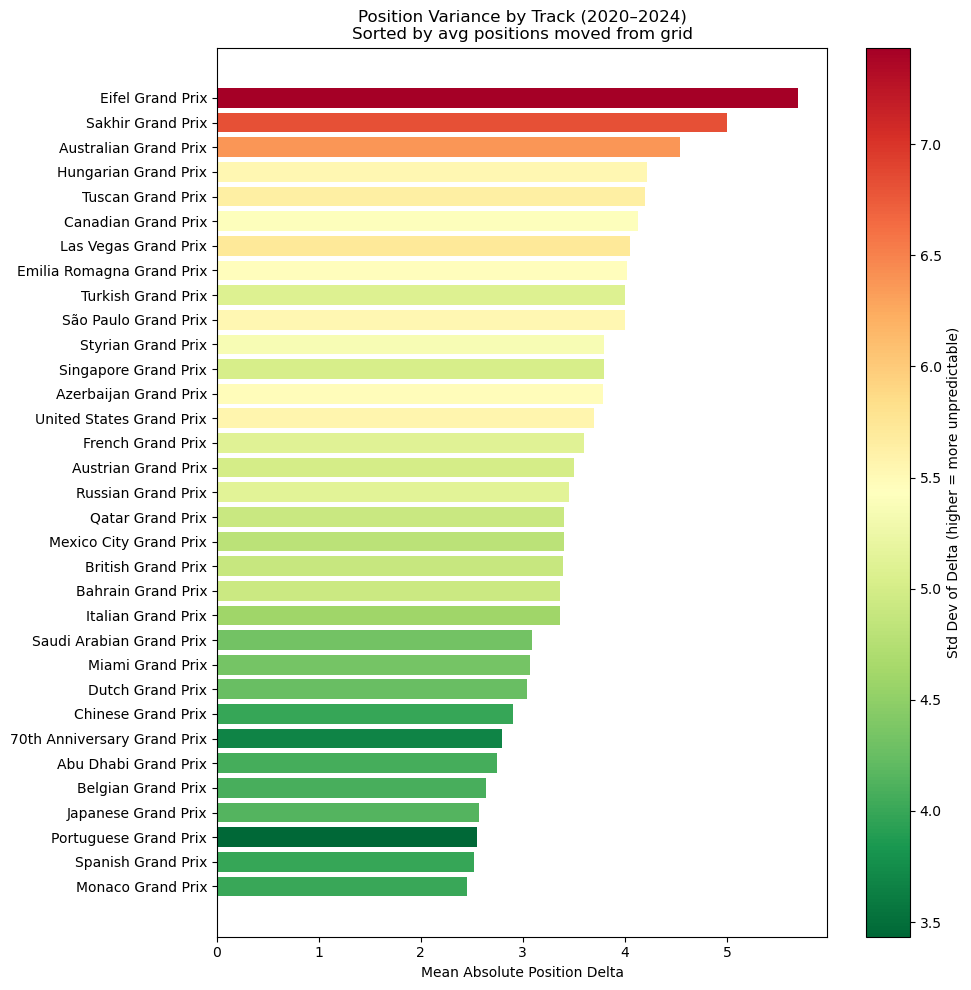

                  EventName  mean_abs_delta  std_delta  median_delta  avg_gained  avg_lost
           Eifel Grand Prix        5.700000   7.433919           1.5    4.750000 -8.142857
          Sakhir Grand Prix        5.000000   6.821020           1.5    3.846154 -7.142857
      Australian Grand Prix        4.542373   6.373436           1.0    3.621622 -7.052632
       Hungarian Grand Prix        4.220000   5.528622           0.0    4.906977 -4.395833
          Tuscan Grand Prix        4.200000   5.638215           1.0    3.818182 -7.000000
        Canadian Grand Prix        4.133333   5.411851           1.0    3.757576 -5.391304
       Las Vegas Grand Prix        4.050000   5.724442           0.0    4.764706 -5.062500
  Emilia Romagna Grand Prix        4.025000   5.451745           1.0    3.926829 -5.366667
       São Paulo Grand Prix        4.000000   5.532413           1.0    3.809524 -5.333333
         Turkish Grand Prix        4.000000   5.088952           0.5    4.000000 -5.000000

In [41]:
# === EDA: Position Variance by Track (2020–2024) ===
import matplotlib.cm as cm

_raw = pd.read_csv('data/f1_2020_2025.csv')
_raw = _raw[_raw['Season'] <= 2024].copy()

# Positive delta = gained positions, negative = lost
_raw['positions_delta'] = _raw['GridPosition'] - _raw['RacePosition']

def _avg_gained(x):
    gains = x[x > 0]
    return gains.mean() if len(gains) > 0 else 0.0

def _avg_lost(x):
    losses = x[x < 0]
    return losses.mean() if len(losses) > 0 else 0.0

track_stats = _raw.groupby('EventName')['positions_delta'].agg(
    mean_abs_delta=lambda x: x.abs().mean(),
    std_delta='std',
    median_delta='median',
    avg_gained=_avg_gained,
    avg_lost=_avg_lost
).reset_index().sort_values('mean_abs_delta', ascending=True)

# Horizontal bar chart colored by std deviation
fig, ax = plt.subplots(figsize=(10, 10))
norm = plt.Normalize(track_stats['std_delta'].min(), track_stats['std_delta'].max())
colors = cm.RdYlGn_r(norm(track_stats['std_delta']))
ax.barh(track_stats['EventName'], track_stats['mean_abs_delta'], color=colors)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Std Dev of Delta (higher = more unpredictable)')
ax.set_xlabel('Mean Absolute Position Delta')
ax.set_title('Position Variance by Track (2020–2024)\nSorted by avg positions moved from grid')
plt.tight_layout()
plt.show()

print(track_stats.sort_values('mean_abs_delta', ascending=False).to_string(index=False))

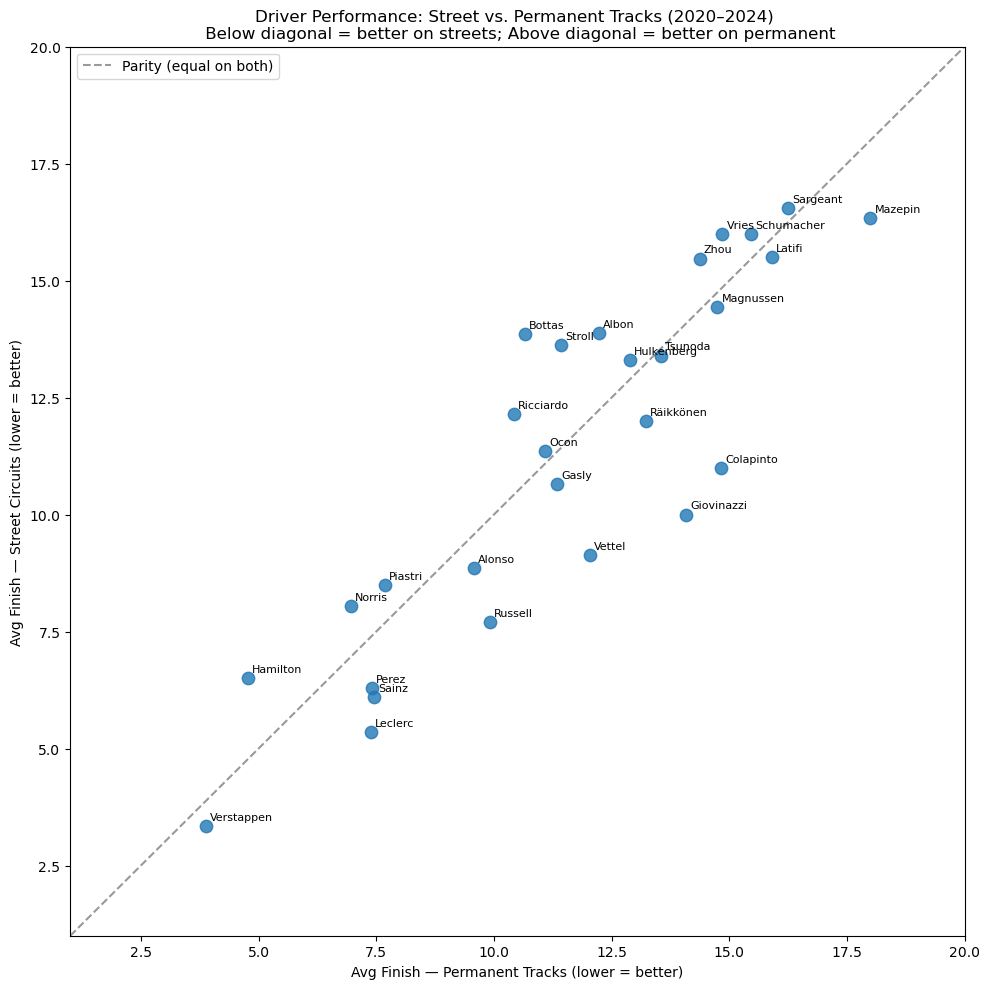

                    street_avg   perm_avg  street_count  perm_count
FullName                                                           
Max Verstappen        3.350000   3.873563            20          87
Charles Leclerc       5.350000   7.379310            20          87
Carlos Sainz          6.105263   7.448276            19          87
Sergio Perez          6.300000   7.411765            20          85
Lewis Hamilton        6.500000   4.779070            20          86
George Russell        7.700000   9.908046            20          87
Lando Norris          8.050000   6.965517            20          87
Oscar Piastri         8.500000   7.676471            12          34
Fernando Alonso       8.850000   9.571429            20          70
Sebastian Vettel      9.142857  12.038462             7          52
Antonio Giovinazzi   10.000000  14.083333             3          36
Pierre Gasly         10.650000  11.344828            20          87
Franco Colapinto     11.000000  14.833333       

In [42]:
# === EDA: Driver Performance — Street vs. Permanent Tracks (2020–2024) ===

_street_circuits = {
    'Monaco Grand Prix',
    'Singapore Grand Prix',
    'Azerbaijan Grand Prix',
    'Las Vegas Grand Prix',
    'Miami Grand Prix',
    'Saudi Arabian Grand Prix',
}

_raw2 = pd.read_csv('data/f1_2020_2025.csv')
_raw2 = _raw2[_raw2['Season'] <= 2024].copy()
_raw2['track_type'] = _raw2['EventName'].apply(
    lambda e: 'Street' if e in _street_circuits else 'Permanent'
)

_street_avg = (
    _raw2[_raw2['track_type'] == 'Street']
    .groupby('FullName')['RacePosition']
    .agg(street_avg='mean', street_count='count')
)
_perm_avg = (
    _raw2[_raw2['track_type'] == 'Permanent']
    .groupby('FullName')['RacePosition']
    .agg(perm_avg='mean', perm_count='count')
)

_driver_stats = _street_avg.join(_perm_avg, how='inner')
_driver_stats = _driver_stats[
    (_driver_stats['street_count'] >= 3) & (_driver_stats['perm_count'] >= 3)
]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(_driver_stats['perm_avg'], _driver_stats['street_avg'], s=80, alpha=0.8)

for name, row in _driver_stats.iterrows():
    ax.annotate(
        name.split()[-1],
        (row['perm_avg'], row['street_avg']),
        fontsize=8, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

ax.plot([1, 20], [1, 20], 'k--', alpha=0.4, label='Parity (equal on both)')
ax.set_xlim(1, 20)
ax.set_ylim(1, 20)
ax.set_xlabel('Avg Finish — Permanent Tracks (lower = better)')
ax.set_ylabel('Avg Finish — Street Circuits (lower = better)')
ax.set_title('Driver Performance: Street vs. Permanent Tracks (2020–2024) \n Below diagonal = better on streets; Above diagonal = better on permanent')
ax.legend()
plt.tight_layout()
plt.show()

print(_driver_stats[['street_avg', 'perm_avg', 'street_count', 'perm_count']].sort_values('street_avg').to_string())

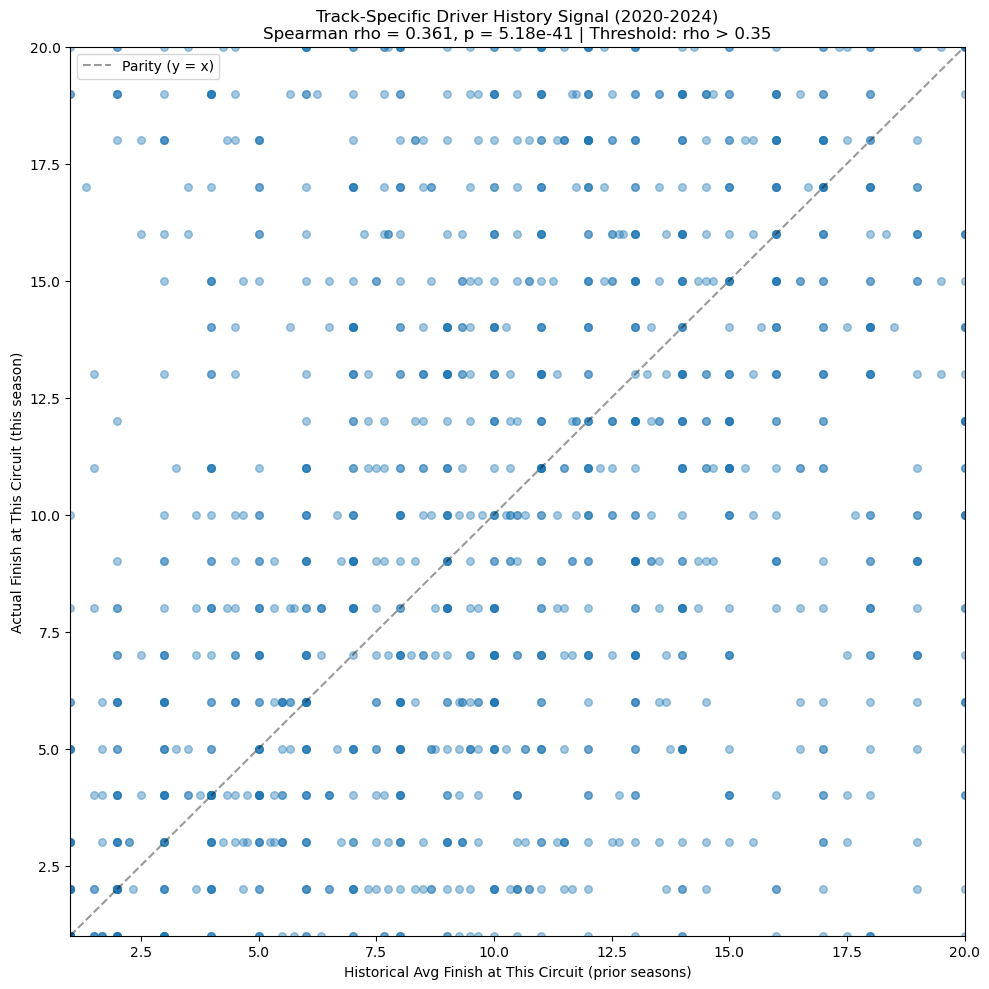

Pooled Spearman rho: 0.361  (p-value: 5.18e-41)
Number of driver-circuit-season pairs: 1287

Signal assessment: WORTH ADDING as feature


In [43]:
# === EDA: Track-Specific Driver History Signal (2020–2024) ===
from scipy.stats import spearmanr

_raw3 = pd.read_csv('data/f1_2020_2025.csv')
_raw3 = _raw3[_raw3['Season'] <= 2024].copy()

# For each driver x circuit x season, compute historical avg finish from prior seasons
_pairs = []
for (driver, circuit), group in _raw3.groupby(['FullName', 'EventName']):
    group = group.sort_values('Season')
    seasons = group['Season'].values
    finishes = group['RacePosition'].values
    for i in range(1, len(seasons)):
        historical_avg = finishes[:i].mean()
        actual_finish = finishes[i]
        if not np.isnan(historical_avg) and not np.isnan(actual_finish):
            _pairs.append({
                'driver': driver,
                'circuit': circuit,
                'season': seasons[i],
                'historical_avg': historical_avg,
                'actual_finish': actual_finish,
            })

_pairs_df = pd.DataFrame(_pairs)

# Pooled Spearman correlation
_rho, _pval = spearmanr(_pairs_df['historical_avg'], _pairs_df['actual_finish'])

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(_pairs_df['historical_avg'], _pairs_df['actual_finish'], s=30, alpha=0.4)
ax.plot([1, 20], [1, 20], 'k--', alpha=0.4, label='Parity (y = x)')
ax.set_xlim(1, 20)
ax.set_ylim(1, 20)
ax.set_xlabel('Historical Avg Finish at This Circuit (prior seasons)')
ax.set_ylabel('Actual Finish at This Circuit (this season)')
ax.set_title(f'Track-Specific Driver History Signal (2020-2024)\nSpearman rho = {_rho:.3f}, p = {_pval:.2e} | Threshold: rho > 0.35')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pooled Spearman rho: {_rho:.3f}  (p-value: {_pval:.2e})')
print(f'Number of driver-circuit-season pairs: {len(_pairs_df)}')
print(f'\nSignal assessment: {"WORTH ADDING as feature" if _rho > 0.35 else "Too weak to add"}')

In [44]:
# === Baseline: GridPosition-Only Tau (2025) ===
# How well does qualifying position alone predict race finish?
# Compares against the model mean Kendall's Tau as a sanity check.
from scipy.stats import kendalltau as _kendalltau

_baseline_raw = pd.read_csv('data/f1_2020_2025.csv')
_baseline_2025 = _baseline_raw[_baseline_raw['Season'] == 2025].copy()
_baseline_2025 = _baseline_2025.dropna(subset=['GridPosition', 'RacePosition'])

_baseline_tau_scores = {}
for _race in _baseline_2025['EventName'].unique():
      _rdf = _baseline_2025[_baseline_2025['EventName'] == _race]

      finished_drivers = raw_2025[
          (raw_2025['EventName'] == _race) &
          (raw_2025['Status'].isin(['Finished', 'Lapped']))
      ]['FullName']

      _rdf = _rdf[_rdf['FullName'].isin(finished_drivers)]

      if len(_rdf) < 2:
          continue
      _tau, _ = _kendalltau(_rdf['RacePosition'], _rdf['GridPosition'])
      _baseline_tau_scores[_race] = round(_tau, 3)

_mean_baseline_tau = round(np.mean(list(_baseline_tau_scores.values())), 3)

print(f"Baseline (GridPosition only) — Mean Kendall's Tau: {_mean_baseline_tau}")
print(f"Model (all features)        — Mean Kendall's Tau: 0.496")
print(f"{'Race':<35} {'Baseline Tau':>12}")
print("-" * 49)
for _race, _tau in sorted(_baseline_tau_scores.items(), key=lambda x: -x[1]):
    print(f"{_race:<35} {_tau:>12.3f}")


Baseline (GridPosition only) — Mean Kendall's Tau: 0.606
Model (all features)        — Mean Kendall's Tau: 0.496
Race                                Baseline Tau
-------------------------------------------------
Japanese Grand Prix                        0.874
Saudi Arabian Grand Prix                   0.804
Monaco Grand Prix                          0.752
Hungarian Grand Prix                       0.731
Italian Grand Prix                         0.725
Azerbaijan Grand Prix                      0.719
Miami Grand Prix                           0.717
Austrian Grand Prix                        0.667
Mexico City Grand Prix                     0.667
Qatar Grand Prix                           0.667
Canadian Grand Prix                        0.662
United States Grand Prix                   0.649
São Paulo Grand Prix                       0.647
Singapore Grand Prix                       0.642
Bahrain Grand Prix                         0.634
Abu Dhabi Grand Prix                       0.621
Span

## Model Training

Random Forest Regressor trained on 2020-2024, evaluated on 2025.
Temporal split prevents data leakage from future seasons.

In [45]:

# Temporal train/eval split — no random splitting
df_train = df[df['Season'] <= 2024]
df_eval = df[df['Season'] == 2025]

X_train = df_train.drop(columns=['FinishPosition', 'Season', 'Round'])
y_train = df_train['FinishPosition']
X_val = df_eval.drop(columns=['FinishPosition', 'Season', 'Round'])
y_val = df_eval['FinishPosition']

# Drop rows with NaN target
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]


print(X_train.columns)


Index(['GridPosition', 'driver_rolling_avg_5', 'driver_rolling_std_5',
       'driver_last_finish', 'team_rolling_avg_5', 'quali_delta_to_teammate',
       'driver_track_history_avg', 'driver_rolling_avg_timedelta_5',
       'Team_Alfa Romeo', 'Team_Alfa Romeo Racing', 'Team_AlphaTauri',
       'Team_Alpine', 'Team_Aston Martin', 'Team_Ferrari', 'Team_Haas F1 Team',
       'Team_Kick Sauber', 'Team_McLaren', 'Team_Mercedes', 'Team_RB',
       'Team_Racing Bulls', 'Team_Racing Point', 'Team_Red Bull Racing',
       'Team_Renault', 'Team_Williams'],
      dtype='object')


In [46]:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
from scipy.stats import kendalltau
import json
import os

def kendalltau_scorer(y_true,y_pred):
    corr, _ = kendalltau(y_true, y_pred)
    return corr

tau_scorer = make_scorer(kendalltau_scorer, greater_is_better = True)
tscv = TimeSeriesSplit(n_splits = 5)


X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

chrono_cols = ['Season', 'Round']

sorted_index = df_ref.loc[X_train.index].sort_values(by=chrono_cols).index

X_train = X_train.loc[sorted_index]
y_train = y_train.loc[sorted_index]

path = 'best_params.json'
best_params = None
if os.path.exists(path):
    with open(path) as f:
        best_params = json.load(f)
    rf = RandomForestRegressor(random_state = 42, **best_params)
    rf.fit(X_train, y_train)
else:
    with open ('best_params.json', 'w') as f:
        rf_grid = {"n_estimators": [50,100,150,200], "max_depth" : [5,10,15], "min_samples_split": [2, 5, 6, 7]}
        rf = GridSearchCV(RandomForestRegressor(random_state= 42), rf_grid, cv = tscv, scoring = tau_scorer)
        rf.fit(X_train, y_train)
        json.dump(rf.best_params_, f, indent = 2)

y_pred = rf.predict(X_val)

df_eval_ref = df_ref.loc[X_val.index].copy()

# RF predictions
df_eval_ref['Predicted'] = y_pred
df_eval_ref['Predicted_Rank'] = df_eval_ref.groupby('EventName')['Predicted'].rank(method='first').astype(int)




## Evaluation

Per-race metrics: Kendall's Tau (ranking quality), MAE (positions off),
AP@5 (top-5 ordering), Top-5 Precision (top-5 identification).

In [47]:
raw_2025 = pd.read_csv('data/f1_2025.csv')

tau_full_scores  = {}
tau_clean_scores = {}
mae_scores       = {}
ap5_scores       = {}
top5_scores      = {}

for race in df_eval_ref['EventName'].unique():
    race_df_full = df_eval_ref[df_eval_ref['EventName'] == race].dropna(subset=['FinishPosition'])

    finished_drivers = raw_2025[
        (raw_2025['EventName'] == race) &
        (raw_2025['Status'].isin(['Finished', 'Lapped']))
    ]['FullName']
    race_df_clean = race_df_full[race_df_full['FullName'].isin(finished_drivers)]

    tau_full, _  = kendalltau(race_df_full['FinishPosition'],  race_df_full['Predicted_Rank'])
    tau_clean, _ = kendalltau(race_df_clean['FinishPosition'], race_df_clean['Predicted_Rank'])

    mae = (race_df_clean['FinishPosition'] - race_df_clean['Predicted_Rank']).abs().mean()
    actual_top5 = (race_df_clean['FinishPosition'] <= 5).astype(int)
    ap5 = average_precision_score(actual_top5, -race_df_clean['Predicted_Rank'])
    predicted_top5_names = set(race_df_clean.nsmallest(5, 'Predicted_Rank')['FullName'])
    actual_top5_names    = set(race_df_clean.nsmallest(5, 'FinishPosition')['FullName'])
    top5_precision = len(predicted_top5_names & actual_top5_names) / 5

    tau_full_scores[race]  = round(tau_full, 3)
    tau_clean_scores[race] = round(tau_clean, 3)
    mae_scores[race]       = round(mae, 3)
    ap5_scores[race]       = round(ap5, 3)
    top5_scores[race]      = round(top5_precision, 3)

mean_tau_full  = round(np.mean(list(tau_full_scores.values())), 3)
mean_tau_clean = round(np.mean(list(tau_clean_scores.values())), 3)
mean_mae       = round(np.mean(list(mae_scores.values())), 3)
mean_ap5       = round(np.mean(list(ap5_scores.values())), 3)
mean_top5      = round(np.mean(list(top5_scores.values())), 3)

print("=== Random Forest ===")
print(f"Mean Tau (full field):     {mean_tau_full:.3f}")
print(f"Mean Tau (finishers only): {mean_tau_clean:.3f}")
print(f"Mean MAE:                  {mean_mae:.3f} positions")
print(f"Mean AP@5:                 {mean_ap5:.3f}")
print(f"Mean Top-5 Precision:      {mean_top5:.3f}")

=== Random Forest ===
Mean Tau (full field):     0.539
Mean Tau (finishers only): 0.645
Mean MAE:                  2.682 positions
Mean AP@5:                 0.898
Mean Top-5 Precision:      0.850


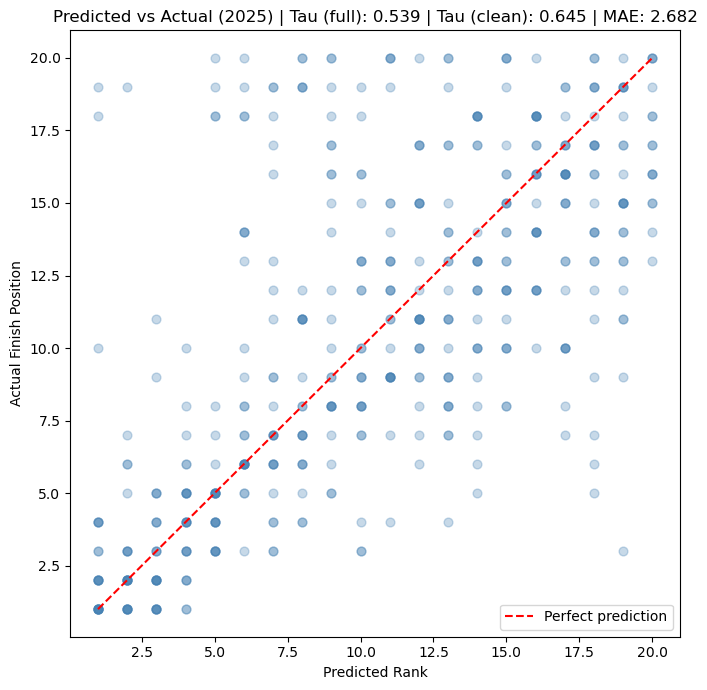

In [48]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_eval_ref['Predicted_Rank'], df_eval_ref['FinishPosition'],
           alpha=0.3, edgecolors='steelblue', facecolors='steelblue', s=40)
ax.plot([1, 20], [1, 20], color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Predicted Rank')
ax.set_ylabel('Actual Finish Position')
ax.set_title(
    f"Predicted vs Actual (2025) | "
    f"Tau (full): {np.mean(list(tau_full_scores.values())):.3f} | "
    f"Tau (clean): {np.mean(list(tau_clean_scores.values())):.3f} | "
    f"MAE: {np.mean(list(mae_scores.values())):.3f}"
)
ax.legend()
plt.tight_layout()
plt.show()


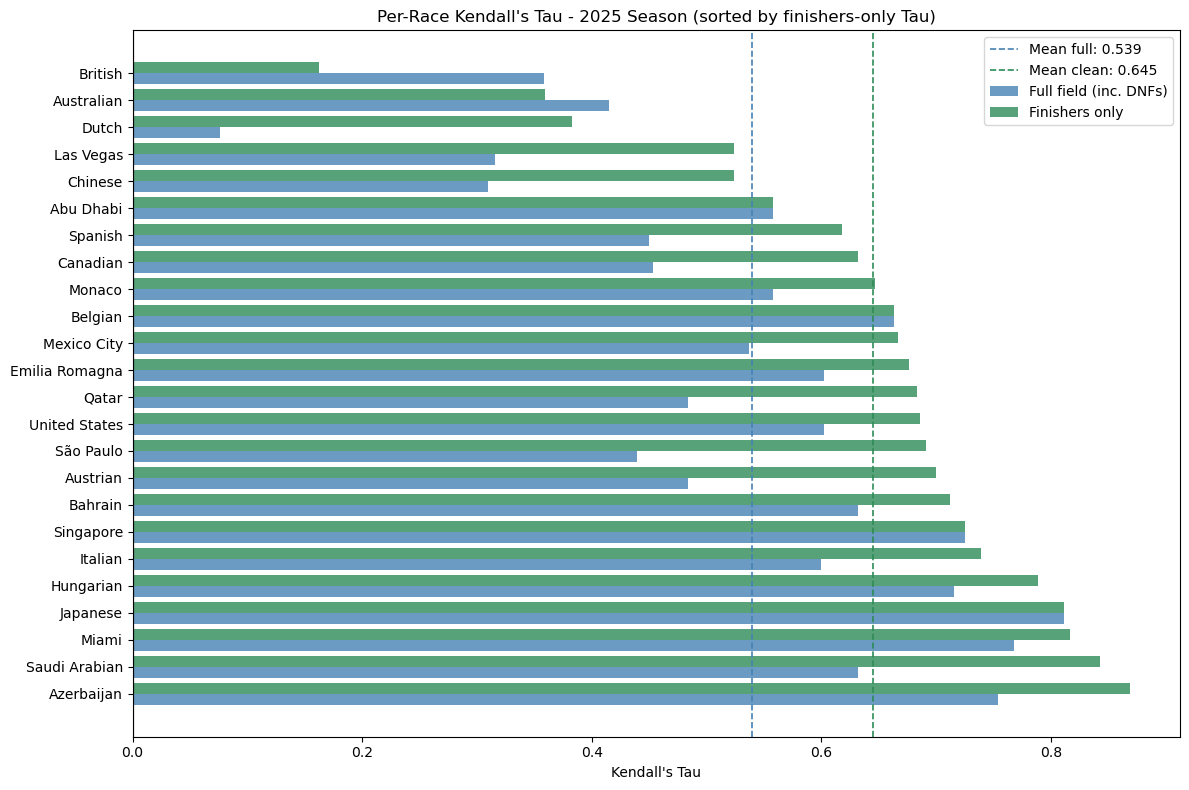

In [49]:
# Per-race Kendall's Tau bar chart (full field vs finishers only)
races_sorted = sorted(tau_full_scores.keys(), key=lambda r: -tau_clean_scores[r])
race_names   = [r.replace(' Grand Prix', '') for r in races_sorted]
taus_full    = [tau_full_scores[r]  for r in races_sorted]
taus_clean   = [tau_clean_scores[r] for r in races_sorted]

x     = np.arange(len(race_names))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(x - width/2, taus_full,  width, label='Full field (inc. DNFs)', color='steelblue', alpha=0.8)
ax.barh(x + width/2, taus_clean, width, label='Finishers only',         color='seagreen',  alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(race_names)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(np.mean(taus_full),  color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Mean full: {np.mean(taus_full):.3f}')
ax.axvline(np.mean(taus_clean), color='seagreen',  linestyle='--', linewidth=1.2,
           label=f'Mean clean: {np.mean(taus_clean):.3f}')
ax.set_xlabel("Kendall's Tau")
ax.set_title("Per-Race Kendall's Tau - 2025 Season (sorted by finishers-only Tau)")
ax.legend()
plt.tight_layout()
plt.show()


In [50]:
# 2025 Metrics: GridPosition-only vs Model Predictions
import os
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import average_precision_score

# Load 2025 actuals
raw        = pd.read_csv("data/f1_2020_2025.csv")
actual_2025 = raw[raw["Season"] == 2025].copy()

# raw_2025 used for DNF filtering (already loaded in eval-metrics cell, reload here for safety)
_raw_2025 = pd.read_csv("data/f1_2025.csv")

def _finished_drivers(race):
    return _raw_2025[
        (_raw_2025["EventName"] == race) &
        (_raw_2025["Status"].isin(["Finished", "Lapped"]))
    ]["FullName"]

# ========== Baseline: GridPosition only ==========
base = actual_2025.dropna(subset=["GridPosition", "RacePosition"]).copy()

tau_b_full, tau_b_clean, mae_b, ap5_b, top5_b = {}, {}, {}, {}, {}
for race in base["EventName"].unique():
    rdf_full = base[base["EventName"] == race]
    if len(rdf_full) < 2:
        continue

    rdf_clean = rdf_full[rdf_full["FullName"].isin(_finished_drivers(race))]

    tau_full,  _ = kendalltau(rdf_full["RacePosition"],  rdf_full["GridPosition"])
    tau_clean, _ = kendalltau(rdf_clean["RacePosition"], rdf_clean["GridPosition"])
    mae     = (rdf_clean["RacePosition"] - rdf_clean["GridPosition"]).abs().mean()
    act_top5 = (rdf_clean["RacePosition"] <= 5).astype(int)
    ap5      = average_precision_score(act_top5, -rdf_clean["GridPosition"])
    pred_top5 = set(rdf_clean.nsmallest(5, "GridPosition")["FullName"])
    act_top5n = set(rdf_clean.nsmallest(5, "RacePosition")["FullName"])

    tau_b_full[race]  = round(tau_full, 3)
    tau_b_clean[race] = round(tau_clean, 3)
    mae_b[race]       = round(mae, 3)
    ap5_b[race]       = round(ap5, 3)
    top5_b[race]      = round(len(pred_top5 & act_top5n) / 5, 3)

mean_tau_b_full  = round(np.mean(list(tau_b_full.values())),  3) if tau_b_full  else float("nan")
mean_tau_b_clean = round(np.mean(list(tau_b_clean.values())), 3) if tau_b_clean else float("nan")
mean_mae_b       = round(np.mean(list(mae_b.values())),       3) if mae_b       else float("nan")
mean_ap5_b       = round(np.mean(list(ap5_b.values())),       3) if ap5_b       else float("nan")
mean_top5_b      = round(np.mean(list(top5_b.values())),      3) if top5_b      else float("nan")

# ========== Model: Predicted_Rank from saved CSV ==========
if not os.path.exists("f1_2025_predictions.csv"):
    print("Missing f1_2025_predictions.csv — run your prediction cell/script first.")
else:
    preds = pd.read_csv("f1_2025_predictions.csv")
    j = preds.merge(
        actual_2025[["EventName", "FullName", "RacePosition"]],
        on=["EventName", "FullName"],
        how="left"
    ).dropna(subset=["RacePosition"])

    tau_m_full, tau_m_clean, mae_m, ap5_m, top5_m = {}, {}, {}, {}, {}
    for race in j["EventName"].unique():
        rdf_full = j[j["EventName"] == race]
        if len(rdf_full) < 2:
            continue

        rdf_clean = rdf_full[rdf_full["FullName"].isin(_finished_drivers(race))]

        tau_full,  _ = kendalltau(rdf_full["RacePosition"],  rdf_full["Predicted_Rank"])
        tau_clean, _ = kendalltau(rdf_clean["RacePosition"], rdf_clean["Predicted_Rank"])
        mae      = (rdf_clean["RacePosition"] - rdf_clean["Predicted_Rank"]).abs().mean()
        act_top5 = (rdf_clean["RacePosition"] <= 5).astype(int)
        ap5      = average_precision_score(act_top5, -rdf_clean["Predicted_Rank"])
        pred_top5 = set(rdf_clean.nsmallest(5, "Predicted_Rank")["FullName"])
        act_top5n = set(rdf_clean.nsmallest(5, "RacePosition")["FullName"])

        tau_m_full[race]  = round(tau_full, 3)
        tau_m_clean[race] = round(tau_clean, 3)
        mae_m[race]       = round(mae, 3)
        ap5_m[race]       = round(ap5, 3)
        top5_m[race]      = round(len(pred_top5 & act_top5n) / 5, 3)

    mean_tau_m_full  = round(np.mean(list(tau_m_full.values())),  3) if tau_m_full  else float("nan")
    mean_tau_m_clean = round(np.mean(list(tau_m_clean.values())), 3) if tau_m_clean else float("nan")
    mean_mae_m       = round(np.mean(list(mae_m.values())),       3) if mae_m       else float("nan")
    mean_ap5_m       = round(np.mean(list(ap5_m.values())),       3) if ap5_m       else float("nan")
    mean_top5_m      = round(np.mean(list(top5_m.values())),      3) if top5_m      else float("nan")

    # Summary
    print("=== 2025 Mean Metrics ===")
    print(f"{'':30} {'Tau (Full)':>10} {'Tau (Clean)':>12} {'MAE':>7} {'AP@5':>7} {'Top-5':>7}")
    print(f"{'-'*70}")
    print(f"{'Grid only':<30} {mean_tau_b_full:>10} {mean_tau_b_clean:>12} {mean_mae_b:>7} {mean_ap5_b:>7} {mean_top5_b:>7}")
    print(f"{'Model':<30} {mean_tau_m_full:>10} {mean_tau_m_clean:>12} {mean_mae_m:>7} {mean_ap5_m:>7} {mean_top5_m:>7}")

    # Per-race table
    races = sorted(set(tau_b_clean.keys()) | set(tau_m_clean.keys()), key=lambda r: -tau_m_clean.get(r, -999))
    rows = []
    for r in races:
        rows.append({
            "Race":              r,
            "Tau Full (Grid)":   tau_b_full.get(r,  np.nan),
            "Tau Clean (Grid)":  tau_b_clean.get(r, np.nan),
            "Tau Full (Model)":  tau_m_full.get(r,  np.nan),
            "Tau Clean (Model)": tau_m_clean.get(r, np.nan),
            "MAE (Grid)":        mae_b.get(r,       np.nan),
            "MAE (Model)":       mae_m.get(r,       np.nan),
            "AP@5 (Grid)":       ap5_b.get(r,       np.nan),
            "AP@5 (Model)":      ap5_m.get(r,       np.nan),
            "Top-5 (Grid)":      top5_b.get(r,      np.nan),
            "Top-5 (Model)":     top5_m.get(r,      np.nan),
        })
    display(pd.DataFrame(rows))


Missing f1_2025_predictions.csv — run your prediction cell/script first.


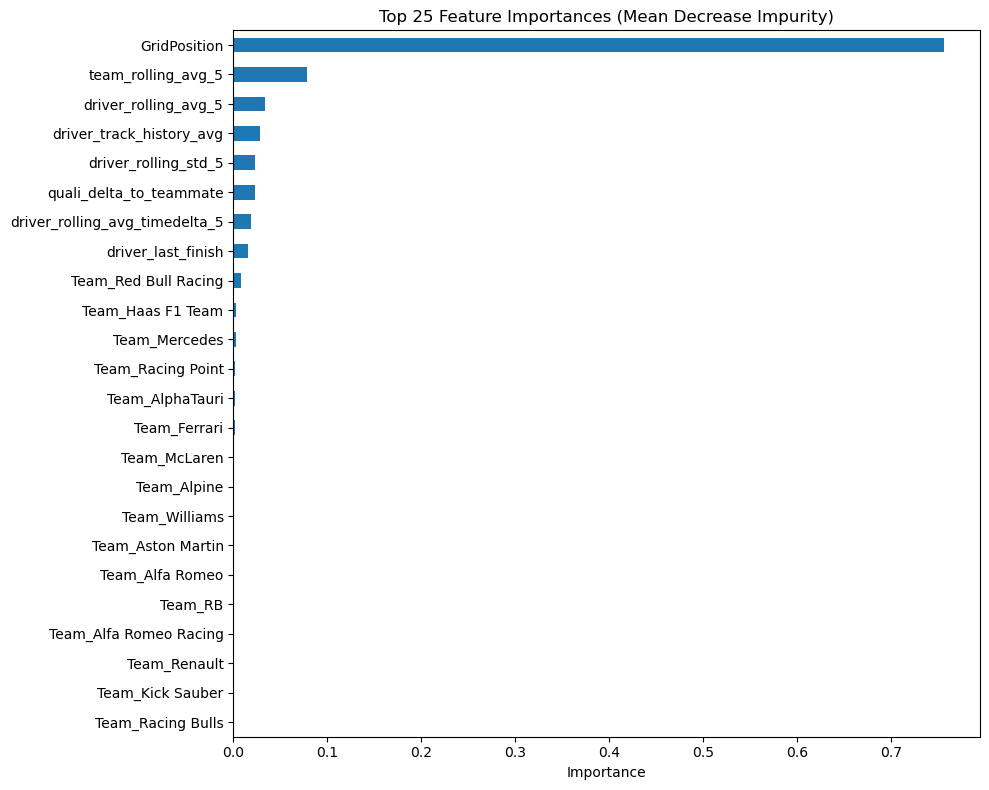

GridPosition                      0.756538
team_rolling_avg_5                0.077852
driver_rolling_avg_5              0.033374
driver_track_history_avg          0.028446
driver_rolling_std_5              0.023299
quali_delta_to_teammate           0.023142
driver_rolling_avg_timedelta_5    0.019150
driver_last_finish                0.015769
Team_Red Bull Racing              0.007857
Team_Haas F1 Team                 0.003034
Team_Mercedes                     0.002317
Team_Racing Point                 0.001914
Team_AlphaTauri                   0.001418
Team_Ferrari                      0.001302
Team_McLaren                      0.001036
Team_Alpine                       0.000947
Team_Williams                     0.000848
Team_Aston Martin                 0.000546
Team_Alfa Romeo                   0.000407
Team_RB                           0.000386
Team_Alfa Romeo Racing            0.000188
Team_Renault                      0.000185
Team_Kick Sauber                  0.000043
Team_Racing

In [51]:
importances = pd.Series(rf.feature_importances_, index= X_train.columns).sort_values(ascending = False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(25).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 25 Feature Importances (Mean Decrease Impurity)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

### Top 3 Accuracy

### Modelling with XGBRank Now

In [57]:
import xgboost as xgb
print(xgb.__version__)

groups_train = df_ref.loc[X_train.index].groupby(["Season", "Round"], sort=False).size().values

y_relevance = (y_train.max() + 1) - y_train  # P1 -> highest relevance score

team_cols   = [c for c in X_train.columns if c.startswith("Team_")]
X_train_xgb = X_train.drop(columns=team_cols)
X_val_xgb   = X_val.drop(columns=team_cols)

xgbpath = "XGB_best_params.json"

if os.path.exists(xgbpath):
    with open(xgbpath) as f:
        best_params = json.load(f)
    print(f"Loaded cached params: {best_params}")
else:
    best_params = {
        "n_estimators":  200,
        "learning_rate": 0.01,
        "max_depth":     3,
        "subsample":     0.7
    }
    with open(xgbpath, "w") as f:
        json.dump(best_params, f, indent=2)
    print(f"Saved default params: {best_params}")

xgb_model = xgb.XGBRanker(objective="rank:pairwise", random_state=42, **best_params)
xgb_model.fit(X_train_xgb, y_relevance, group=groups_train)

xgb_scores = xgb_model.predict(X_val_xgb)
df_eval_ref["XGB_score"] = xgb_scores
df_eval_ref["XGB Rank"]  = df_eval_ref.groupby("EventName")["XGB_score"].rank(ascending=False, method="first").astype(int)
df_eval_ref.sort_values(['Round', 'Predicted_Rank', 'XGB Rank'])[['Season', 'Round', 'EventName', 'FullName',  "FinishPosition", 'Predicted_Rank', 'XGB Rank']].to_csv('f1_2025_predictions.csv', index=False)
print("Models trained. Predictions saved to f1_2025_predictions.csv")


3.2.0
Loaded cached params: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}
Models trained. Predictions saved to f1_2025_predictions.csv


#### XGBoost Evaluation

In [58]:
xgb_tau_full_scores  = {}
xgb_tau_clean_scores = {}
xgb_mae_scores       = {}
xgb_ap5_scores       = {}
xgb_top5_scores      = {}

for race in df_eval_ref["EventName"].unique():
    race_df_full = df_eval_ref[df_eval_ref["EventName"] == race].dropna(subset=["FinishPosition"])

    finished_drivers = raw_2025[
        (raw_2025["EventName"] == race) &
        (raw_2025["Status"].isin(["Finished", "Lapped"]))
    ]["FullName"]
    race_df_clean = race_df_full[race_df_full["FullName"].isin(finished_drivers)]

    tau_full,  _ = kendalltau(race_df_full["FinishPosition"],  race_df_full["XGB Rank"])
    tau_clean, _ = kendalltau(race_df_clean["FinishPosition"], race_df_clean["XGB Rank"])

    mae = (race_df_clean["FinishPosition"] - race_df_clean["XGB Rank"]).abs().mean()
    actual_top5 = (race_df_clean["FinishPosition"] <= 5).astype(int)
    ap5 = average_precision_score(actual_top5, -race_df_clean["XGB Rank"])
    predicted_top5_names = set(race_df_clean.nsmallest(5, "XGB Rank")["FullName"])
    actual_top5_names    = set(race_df_clean.nsmallest(5, "FinishPosition")["FullName"])
    top5_precision = len(predicted_top5_names & actual_top5_names) / 5

    xgb_tau_full_scores[race]  = round(tau_full, 3)
    xgb_tau_clean_scores[race] = round(tau_clean, 3)
    xgb_mae_scores[race]       = round(mae, 3)
    xgb_ap5_scores[race]       = round(ap5, 3)
    xgb_top5_scores[race]      = round(top5_precision, 3)

xgb_mean_tau_full  = round(np.mean(list(xgb_tau_full_scores.values())), 3)
xgb_mean_tau_clean = round(np.mean(list(xgb_tau_clean_scores.values())), 3)
xgb_mean_mae       = round(np.mean(list(xgb_mae_scores.values())), 3)
xgb_mean_ap5       = round(np.mean(list(xgb_ap5_scores.values())), 3)
xgb_mean_top5      = round(np.mean(list(xgb_top5_scores.values())), 3)

print("=== Model Comparison ===")
print(f"{"":<30} {"Tau (Full)":>10} {"Tau (Clean)":>12} {"MAE":>7} {"AP@5":>7} {"Top-5":>7}")
print("-" * 70)
print(f"{"Grid only":<30} {mean_tau_b_full:>10} {mean_tau_b_clean:>12} {mean_mae_b:>7} {mean_ap5_b:>7} {mean_top5_b:>7}")
print(f"{"RF":<30} {mean_tau_full:>10} {mean_tau_clean:>12} {mean_mae:>7} {mean_ap5:>7} {mean_top5:>7}")
print(f"{"XGBoost Rank":<30} {xgb_mean_tau_full:>10} {xgb_mean_tau_clean:>12} {xgb_mean_mae:>7} {xgb_mean_ap5:>7} {xgb_mean_top5:>7}")



=== Model Comparison ===
                               Tau (Full)  Tau (Clean)     MAE    AP@5   Top-5
----------------------------------------------------------------------
Grid only                           0.509        0.606   2.858   0.899   0.808
RF                                  0.539        0.645   2.682   0.898    0.85
XGBoost Rank                        0.546        0.657   2.607   0.914    0.85


#### Feature Importances for XGB

In [59]:
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_xgb.columns
).sort_values(ascending=False)
print(xgb_importances)

GridPosition                      0.348766
team_rolling_avg_5                0.136537
driver_rolling_avg_5              0.126159
driver_last_finish                0.095877
driver_track_history_avg          0.085645
driver_rolling_std_5              0.076690
driver_rolling_avg_timedelta_5    0.070257
quali_delta_to_teammate           0.060070
dtype: float32


In [63]:
actual = pd.read_csv('data/f1_2025.csv')
modelled = pd.read_csv('f1_2025_predictions.csv')


#Winner
actual_winner = actual[actual['RacePosition'] == 1].set_index('EventName')['FullName'].to_dict()
predicted_winner = modelled[modelled['Predicted_Rank'] == 1].set_index('EventName')['FullName'].to_dict()
XGB_winner = modelled[modelled['XGB Rank'] == 1].set_index('EventName')['FullName'].to_dict()

actual_races = set(actual_winner.keys())
predicted_races = set(predicted_winner.keys())
XGB_races = set(XGB_winner.keys())
    
    
common = actual_races.intersection(predicted_races).intersection(XGB_races)
missing = actual_races - common

wrongTally = 0
XGBWrongTally = 0
for i in sorted(common):
    if actual_winner[i] != predicted_winner[i]:
        wrongTally += 1
    if actual_winner[i] != XGB_winner[i]:
        XGBWrongTally += 1

acc = ((len(common) - wrongTally) / len(common)) * 100
XGBacc = ((len(common) - XGBWrongTally) / len(common)) * 100

print(f"Total winner accuracy: {acc}%")
print(f"Total incorrect race guesses from RF: {wrongTally}")
print(f"Total incorrect race guesses from XGB: {wrongTally}")


    


Total winner accuracy: 37.5%
Total incorrect race guesses from RF: 15
Total incorrect race guesses from XGB: 15


In [67]:
pred_podium = modelled[modelled["Predicted_Rank"] <= 3].groupby("EventName")["FullName"].apply(list).to_dict()
XGB_pred_podium = modelled[modelled["XGB Rank"] <= 3].groupby("EventName")["FullName"].apply(list).to_dict()
actual_podium = actual[actual["RacePosition"] <= 3].groupby("EventName")["FullName"].apply(list).to_dict()

total_correct = 0
xgb_correct = 0

for race in sorted(common):
    p = set(pred_podium.get(race, []))
    a = set(actual_podium.get(race, []))
    xgb = set(XGB_pred_podium.get(race, []))    
    
    correct = len(p.intersection(a))
    xgbCorrect = len(xgb.intersection(a))
    
    total_correct += correct
    xgb_correct += xgbCorrect

    print(f"{race}: p: {correct}, xgb: {xgbCorrect}")
    
total_possible = len(common) * 3
overal_podium_acc = (total_correct / total_possible) * 100
xgb_podium_acc = (xgb_correct / total_possible) * 100

print(f"RF Podium Accuracy: {overal_podium_acc:.2f}%")
print(f"XGB Podium Accuracy: {xgb_podium_acc:.2f}%")

Abu Dhabi Grand Prix: p: 2, xgb: 2
Australian Grand Prix: p: 2, xgb: 2
Austrian Grand Prix: p: 3, xgb: 3
Azerbaijan Grand Prix: p: 2, xgb: 2
Bahrain Grand Prix: p: 2, xgb: 3
Belgian Grand Prix: p: 3, xgb: 3
British Grand Prix: p: 2, xgb: 2
Canadian Grand Prix: p: 2, xgb: 2
Chinese Grand Prix: p: 3, xgb: 3
Dutch Grand Prix: p: 2, xgb: 2
Emilia Romagna Grand Prix: p: 3, xgb: 3
Hungarian Grand Prix: p: 2, xgb: 2
Italian Grand Prix: p: 2, xgb: 3
Japanese Grand Prix: p: 3, xgb: 3
Las Vegas Grand Prix: p: 2, xgb: 2
Mexico City Grand Prix: p: 2, xgb: 2
Miami Grand Prix: p: 2, xgb: 2
Monaco Grand Prix: p: 3, xgb: 3
Qatar Grand Prix: p: 1, xgb: 2
Saudi Arabian Grand Prix: p: 2, xgb: 2
Singapore Grand Prix: p: 2, xgb: 2
Spanish Grand Prix: p: 2, xgb: 2
São Paulo Grand Prix: p: 1, xgb: 2
United States Grand Prix: p: 2, xgb: 2
RF Podium Accuracy: 72.22%
XGB Podium Accuracy: 77.78%
